# Sensitivity Analysis

The goal is to check whether the assumptions of ANOVA are reasonable and whether the results are robust to violations.

In [2]:
library(haven)
library(ggplot2)
library(dplyr)
library(plotly)

knitr::opts_chunk$set(echo = TRUE)

In [3]:
df_highschools <- read_sav("./data/STAR_High_Schools.sav")
df_comp_students <- read_sav("./data/Comparison_Students.sav")
df_students <- read_sav("./data/STAR_Students.sav")
df_k3schools <- read_sav("./data/STAR_K-3_Schools.sav")

Failed to find CITYPOP
Failed to find COUNTYPO
Failed to find SCHOOLTY
Failed to find HIGHGRAD
Failed to find GRADELEV
Failed to find MINORITY
Failed to find MINORI_A
Failed to find MINORI_B
Failed to find ENROLLME
Failed to find MEALNUM
Failed to find MEANPCT
Failed to find MEALESTI
Failed to find MINREQUI
Failed to find MATHCRGR
Failed to find SCIENCCR
Failed to find FORLANGC
Failed to find SOCSTUDC
Failed to find COMPUTER
Failed to find ENGLISHC
Failed to find MATHCRUN
Failed to find SCIENCEC
Failed to find FORLAN_A
Failed to find SOCSTU_A
Failed to find COMPUT_A
Failed to find ENGLIS_A
Failed to find NOTGRADN
Failed to find UNIFIEDP
Failed to find LINEARAL
Failed to find OTHERMAT
Failed to find COURSE1
Failed to find COURSE2
Failed to find COURSE3
Failed to find COURSE4
Failed to find COURSE5
Failed to find COURSE6
Failed to find COURSE7
Failed to find COURSE8
Failed to find COURSE9
Failed to find COURSE10
Failed to find COURSE11
Failed to find COURSE12
Failed to find COURSE13
Fail

## Cleaning the Data

The code below produces the same cleaned dataset we used for the **inferential analysis**.  In particular:

* Those who left the study (i.e., K-3) early or joined late were removed.
* Those in regular sized classes with a teacher's aid were removed.

In [8]:
# Filter for no aide
had_aide <- df_students$gkclasstype == 3 | 
  df_students$g1classtype == 3 | 
  df_students$g2classtype == 3 | 
  df_students$g3classtype == 3

df_students_noaide <- df_students[!had_aide,]

# Filter for no aide and were in study all 4 years
df_students_noaide_4years <- df_students[
  !had_aide &
  !is.na(df_students$gkclasstype) &
  !is.na(df_students$g1classtype) &
  !is.na(df_students$g2classtype) &
  !is.na(df_students$g3classtype),
]

# Drop races that are not sufficiently represented
df_students_noaide_4years <- df_students_noaide_4years[
  df_students_noaide_4years$race %in% c(1, 2),
]

# Relevant categorical variables:

df_students_noaide_4years$gksurban <- factor(
  df_students_noaide_4years$gksurban,
  labels = c("Inner City", "Suburban", "Rural", "Urban")
)


df_students_noaide_4years$gender <- factor(
  df_students_noaide_4years$gender,
  labels = c("Male", "Female")
)

# subset for white and black only, since
# other races are not sufficiently represented
df_students_noaide_4years <- subset(
  df_students_noaide_4years,
  race %in% c(1, 2)
)

df_students_noaide_4years$race <- factor(
  df_students_noaide_4years$race,
  labels = c("White", "Black")
)

df_students_noaide_4years$g3freelunch <- factor(
  df_students_noaide_4years$g3freelunch,
  labels = c("Free", "Non-Free")
)

df_students_noaide_4years$gkfreelunch <- factor(
  df_students_noaide_4years$gkfreelunch,
  labels = c("Free", "Non-Free")
)

## Model Diagnostics

> *Question 1: Do smaller class sizes disproportionately benefit low-income students in early elementary school?*

### Fitting the ANOVA model from the inferential analysis

In [ ]:
# QUESTION: Is there a reason we only did an additive model?
model <- aov(
  gktmathss ~ (
    gkclasstype
    + gkfreelunch
    + gksurban
  ),
  data = df_students_noaide_4years
)

summary(model)

              Df  Sum Sq Mean Sq F value   Pr(>F)    
gkclasstype    1   37240   37240  18.993 1.41e-05 ***
gkfreelunch    1   95666   95666  48.790 4.48e-12 ***
gksurban       3    2457     819   0.418     0.74    
Residuals   1336 2619558    1961                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
84 observations deleted due to missingness

### Checking Model Assumptions

Two-way ANOVA relies on several assumptions:

1. Independence of observations (*guaranteed by randomness of RCT*)
2. Normality of residuals (*not important if not testing*)
3. Homogeneity of variance
4. Absence of influential outliers

Diagnostics focus mainly on residual analysis.

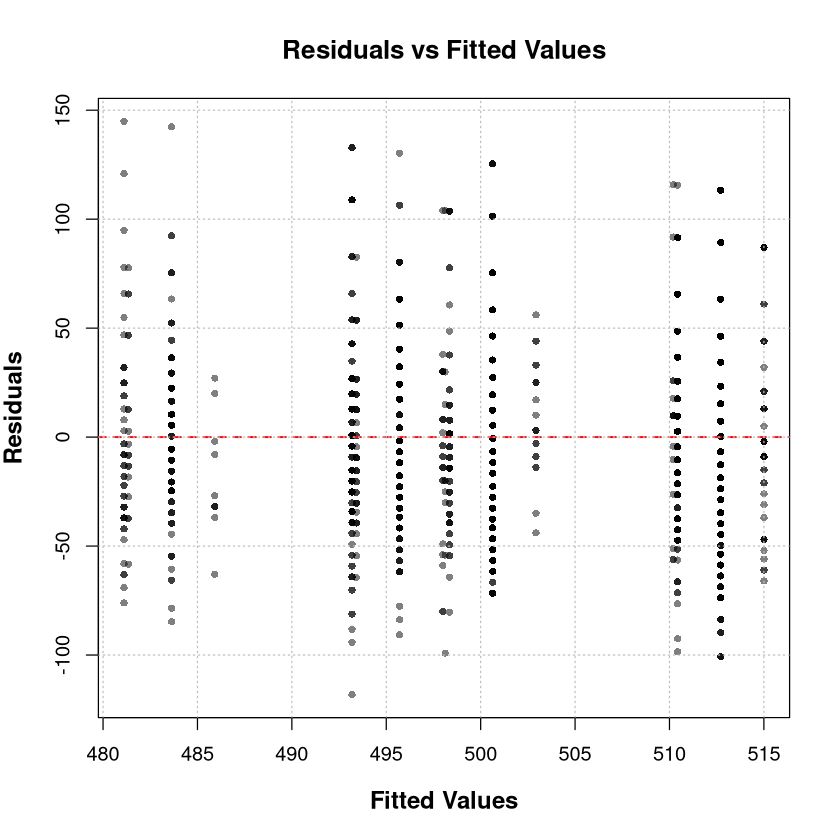

In [ ]:
# Residuals vs fitted value
# Homoscedasticity: residuals should have constant variance
# across fitted values, which does not appear to be the case
res <- residuals(model)
fit <- fitted(model)

plot(
  fit,
  res,
  xlab = "Fitted Values",
  ylab = "Residuals",
  main = "Residuals vs Fitted Values",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.5),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

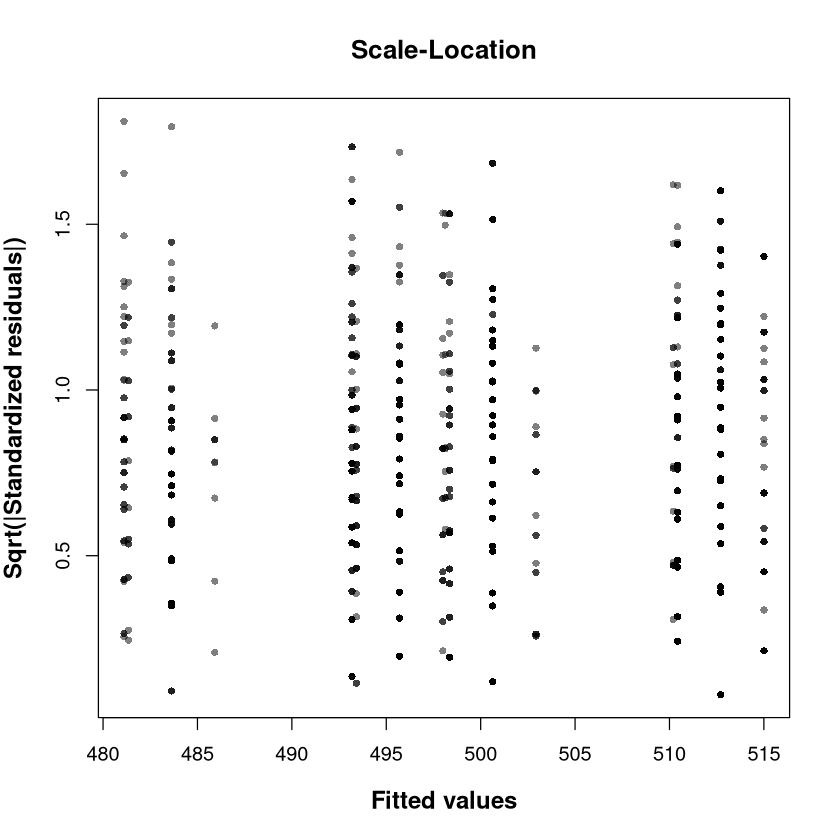

In [12]:
# Scale-location (homoscedasticity)
plot(
  fit,
  sqrt(abs(scale(res))),
  xlab = "Fitted values",
  ylab = "Sqrt(|Standardized residuals|)",
  main = "Scale-Location",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.5),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)

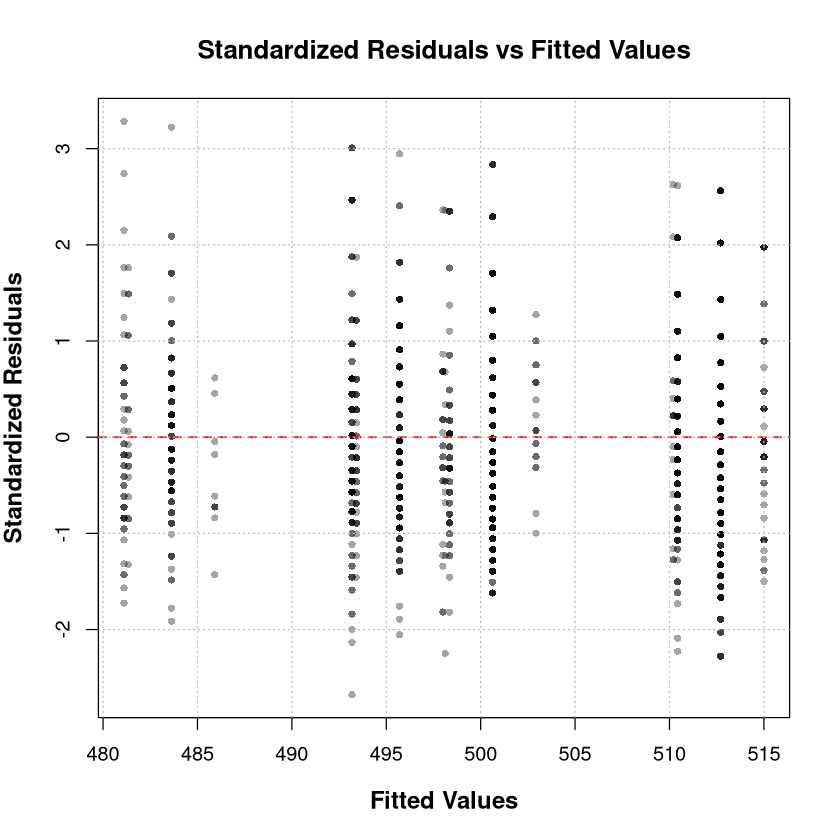

In [13]:
# Outliers may be present, but not many of them.
plot(
  fit,
  rstandard(model),
  xlab = "Fitted Values",
  ylab = "Standardized Residuals",
  main = "Standardized Residuals vs Fitted Values",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.35),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)

abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

In [ ]:
# All three

# # Uncomment this (and `dev.off()`) to save the diagnostic plots as a PNG file
# png(
#   filename = "./img/sensitivity_analysis_q1_diag.png",
#   width = 10,
#   height = 5,
#   units = "in",
#   res = 300
# )

par(mfrow = c(1, 3))

# Residuals vs fitted value
# Homoscedasticity: residuals should have constant variance
# across fitted values, which does not appear to be the case
res <- residuals(model)
fit <- fitted(model)

plot(
  fit,
  res,
  xlab = "Fitted Values",
  ylab = "Residuals",
  main = "Residuals vs Fitted Values",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.5),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

plot(
  fit,
  sqrt(abs(scale(res))),
  xlab = "Fitted values",
  ylab = "Sqrt(|Standardized residuals|)",
  main = "Scale-Location",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.5),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

plot(
  fit,
  rstandard(model),
  xlab = "Fitted Values",
  ylab = "Standardized Residuals",
  main = "Standardized Residuals vs Fitted Values",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.35),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)

abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

par(mfrow = c(1, 1))

# dev.off()

pdf 
  2

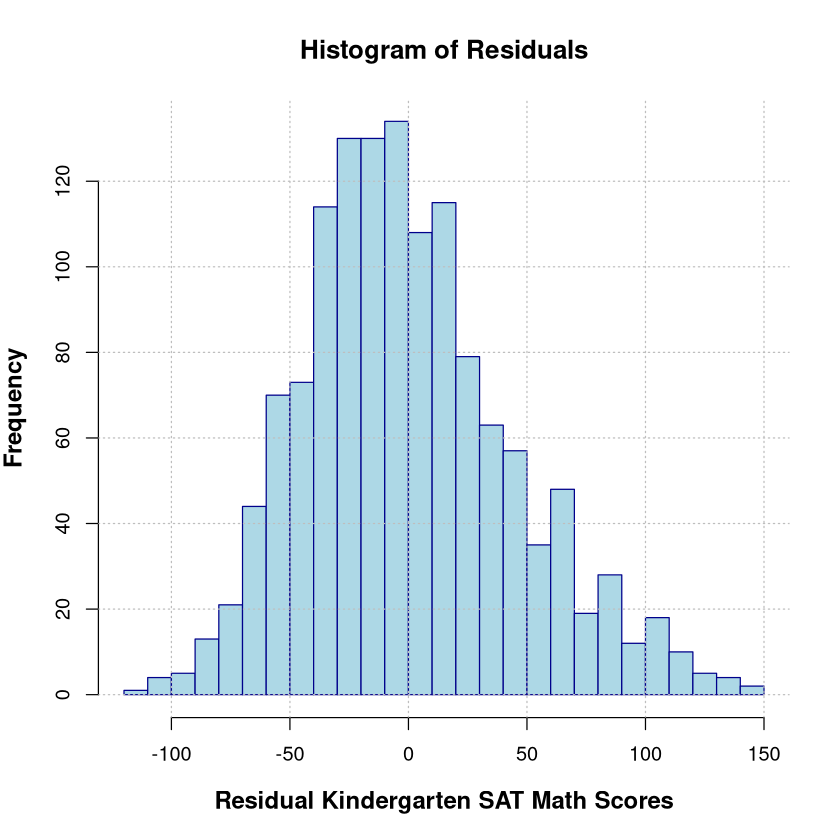

In [29]:
# Residual distribution

# # Uncomment this (and `dev.off()`) to save the plot as a PNG file
# png(
#   filename = "./img/sensitivity_analysis_q1_errors.png",
#   width = 10,
#   height = 5,
#   units = "in",
#   res = 300
# )

hist(
  res,
  breaks = 30,
  main = "Histogram of Residuals",
  xlab = "Residual Kindergarten SAT Math Scores",
  ylab = "Frequency",
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
grid(lty = 3, col = "gray")

# dev.off()

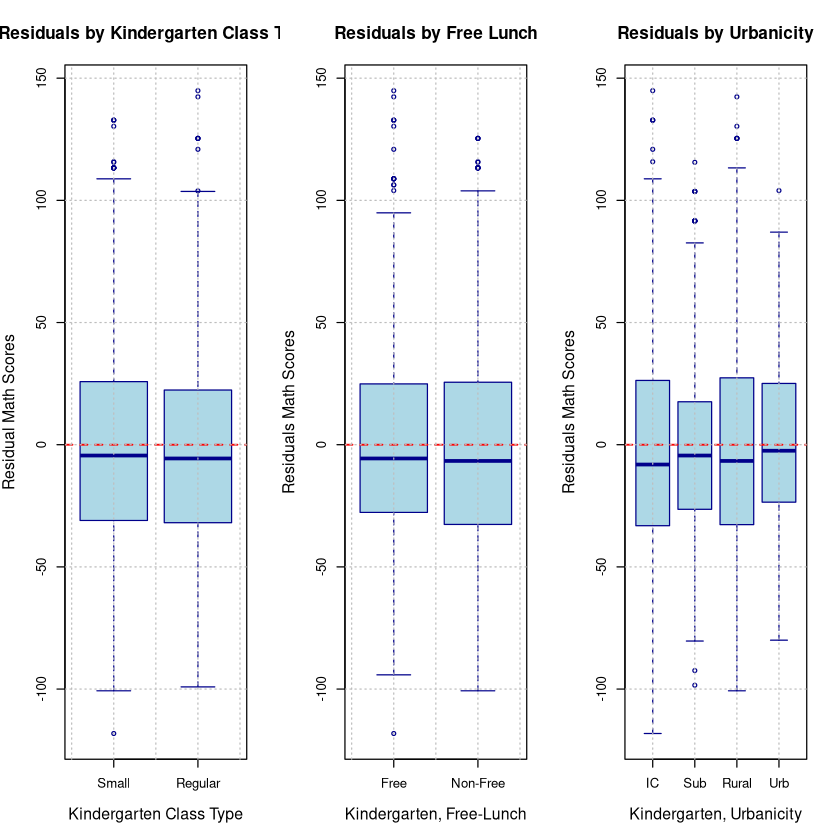

In [31]:
# Residual spread

# # Uncomment this (and `dev.off()`) to save the plot as a PNG file
# png(
#   filename = "./img/sensitivity_analysis_q1_box.png",
#   width = 10,
#   height = 5,
#   units = "in",
#   res = 300
# )

par(mfrow = c(1, 3))

boxplot(
  res ~ model$model$gkclasstype,
  main = "Residuals by Kindergarten Class Type",
  xlab = "Kindergarten Class Type",
  ylab = "Residual Math Scores",
  names = c("Small", "Regular"),
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

boxplot(
  res ~ model$model$gkfreelunch,
  main = "Residuals by Free Lunch",
  xlab = "Kindergarten, Free-Lunch",
  ylab = "Residuals Math Scores",
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

boxplot(
  res ~ model$model$gksurban,
  main = "Residuals by Urbanicity",
  xlab = "Kindergarten, Urbanicity",
  ylab = "Residuals Math Scores",
  names = c("IC", "Sub", "Rural", "Urb"),
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

par(mfrow = c(1, 1))

# dev.off()

#### 3.2 Normality of Residuals

**Shapiro-Wilk Test**

Notes:

* Test is very sensitive to large sample size.
* Graphical checks preferred.

In [24]:
# p-value = 10^{-12} implies NOT normally distributed
shapiro.test(res)


	Shapiro-Wilk normality test

data:  res
W = 0.98119, p-value = 3.213e-12


---

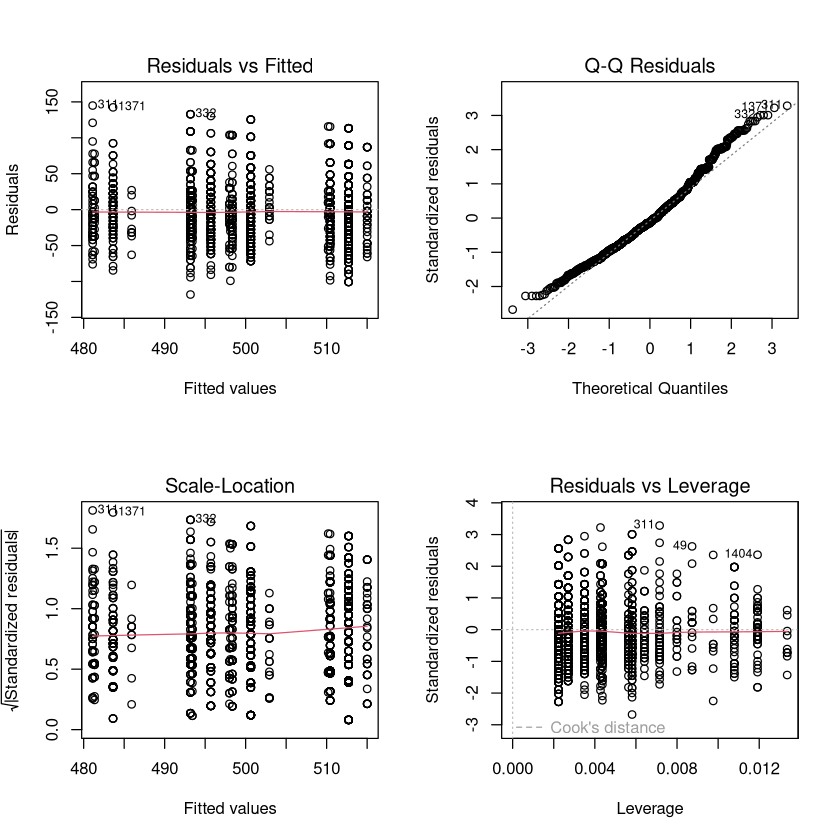

In [25]:
par(mfrow = c(2,2))
plot(model)
par(mfrow = c(1,1))